## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import cv2
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, models
from src.network.training import train
from src.network.evaluation import evaluate, analyze_model_performance
from src.preprocessing.dataset import ChessBoardDataset
from src.utils.dataset_utils import build_transforms, calculate_stats
from src.utils.plotting import visualize_test_samples, plot_training_history
import numpy as np

In [3]:
# Load data

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4
SIZE = 112

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)

# Dataset configurations
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

device: cuda
Training samples: 1800 | Test samples: 205
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 113/113 [00:32<00:00,  3.46it/s]



Calculated training mean: [0.7266303300857544, 0.6799918413162231, 0.5675383806228638]
Calculated training std:  [0.08976191282272339, 0.09742976725101471, 0.08831595629453659]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 13/13 [00:04<00:00,  3.10it/s]


Calculated test mean: [0.7061654329299927, 0.6712028980255127, 0.5853357911109924]
Calculated test std:  [0.13416209816932678, 0.14039230346679688, 0.1279790848493576]



In [9]:
# Define baseline model

def get_baseline_model(num_classes=13):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Replace final FC layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

In [22]:
# Set seed to avoid randomness through different padding values

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(21)

In [23]:
# Padding values to test
padding_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4]

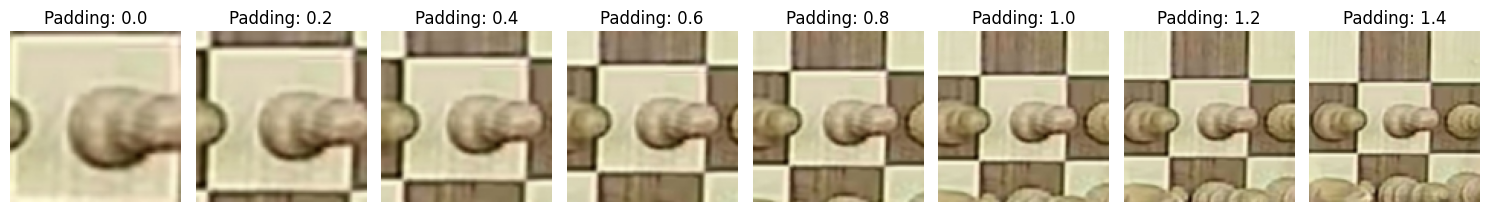

In [24]:
# Visualizing the different padding values

viz_transform = transforms.Compose([
    transforms.Resize((SIZE, SIZE)),
    transforms.ToTensor()
])
    
plt.figure(figsize=(15, 5))

for i, p in enumerate(padding_values):
    ds = ChessBoardDataset(TEST_REAL_DATA_ROOT, transform=viz_transform, padding=p)

    square_idx = 50

    img, label = ds[0]
    img = img[square_idx]
    
    plt.subplot(1, len(padding_values), i+1)
    
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()
        
    plt.imshow(img)
    plt.title(f"Padding: {p}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Experiment

In [25]:
results = {}

print("Starting Padding Experiment...")

for p in padding_values:
    print(f"\n" + "="*40)
    print(f"Testing Padding Value: {p}")
    print("="*40)
    
    # Initialize datasets with new padding
    train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform, padding=p)
    val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=train_transform, padding=p)
    test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform, padding=p)

    # Initialize DataLoaders 
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    
    # Initialize model
    model = get_baseline_model().to(device)

    # Training configuration
    lr = 1e-4
    num_epochs = 5
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Training loop 
    model, history = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=None,
        num_epochs=num_epochs,
        device=device,
        save_path=os.path.join(project_root, f'models/baseline_quality_data_p{p}.pth')
    )

    # Compute accuracy on real test data 
    square_acc, board_acc = evaluate(model, test_real_loader, device)
                
    results[p] = square_acc
    print(f"--> Test Accuracy for padding {p}: {square_acc:.2f}%")

print("\nFinal Padding Experiment Results:", results)

Starting Padding Experiment...

Testing Padding Value: 0.0
Training on cuda for 5 epochs...


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 | Train: Loss=0.0450 Acc=0.9881  Val: Loss=0.0053 Acc=0.9986   [Saved Best]
Epoch 2/5 | Train: Loss=0.0041 Acc=0.9993  Val: Loss=0.0133 Acc=0.9959  
Epoch 3/5 | Train: Loss=0.0045 Acc=0.9990  Val: Loss=0.0037 Acc=0.9989   [Saved Best]
Epoch 4/5 | Train: Loss=0.0035 Acc=0.9993  Val: Loss=0.0010 Acc=1.0000   [Saved Best]
Epoch 5/5 | Train: Loss=0.0023 Acc=0.9996  Val: Loss=0.0005 Acc=0.9999  

Training complete in 5m 59s
Best Val Acc: 1.0000
Starting Evaluation on 205 boards...


Evaluating:   0%|          | 0/103 [00:00<?, ?it/s]

--> Test Accuracy for padding 0.0: 68.85%

Testing Padding Value: 0.2
Training on cuda for 5 epochs...


...

--> Test Accuracy for padding 1.2: 76.01%

Testing Padding Value: 1.4
Training on cuda for 5 epochs...


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 | Train: Loss=0.0896 Acc=0.9737  Val: Loss=0.0248 Acc=0.9919   [Saved Best]
Epoch 2/5 | Train: Loss=0.0070 Acc=0.9983  Val: Loss=0.0453 Acc=0.9887  
Epoch 3/5 | Train: Loss=0.0050 Acc=0.9988  Val: Loss=0.0238 Acc=0.9936   [Saved Best]
Epoch 4/5 | Train: Loss=0.0046 Acc=0.9990  Val: Loss=0.0034 Acc=0.9993   [Saved Best]
Epoch 5/5 | Train: Loss=0.0033 Acc=0.9992  Val: Loss=0.0071 Acc=0.9983  

Training complete in 6m 18s
Best Val Acc: 0.9993
Starting Evaluation on 205 boards...


Evaluating:   0%|          | 0/103 [00:00<?, ?it/s]

--> Test Accuracy for padding 1.4: 75.93%

Final Padding Experiment Results: {0.0: 68.84908536585365, 0.2: 71.17378048780488, 0.4: 68.27743902439025, 0.6: 74.77896341463415, 0.8: 75.79268292682927, 1.0: 76.63871951219512, 1.2: 76.01371951219512, 1.4: 75.9298780487805}
